    Autor:Nelson Leonardo Paez Arias
    Tema: Predicción por Regresión Lineal

# Introducción y contexto

En este trabajo se plantea como problema la estimación del peso corporal a partir de variables físicas, definiendo el peso como la variable objetivo que se desea predecir. Para ello, se identifican como variables predictoras la altura y el sexo, porque ambas presentan una relación directa y significativa con la variación del peso en una población. La elección de un modelo de Regresión Lineal se justifica porque permite analizar y cuantificar la relación entre una variable dependiente y múltiples variables independientes de manera sencilla, interpretable y eficiente, siendo adecuada cuando se busca modelar una tendencia aproximadamente lineal entre las variables y obtener predicciones numéricas continuas.

# Importación de librerias

En esta sección se importan las librerías fundamentales que se utilizarán a lo largo del desarrollo del modelo de regresión lineal. La librería NumPy permite realizar operaciones matemáticas y trabajar con estructuras de datos numéricas de manera eficiente, lo cual es esencial en cálculos relacionados con aprendizaje automático. Por su parte, Pandas facilita la carga, organización y manipulación de los datos provenientes de archivos como CSV o Excel, permitiendo estructurarlos en forma de tablas para su análisis. Finalmente, Matplotlib se utiliza para generar visualizaciones gráficas que ayudan a comprender la relación entre las variables y a interpretar los resultados obtenidos por el modelo. Estas tres librerías constituyen herramientas básicas y ampliamente utilizadas en proyectos de análisis de datos e inteligencia artificial en Python.

In [24]:
# Librerías para cálculo numérico, manejo de datos en tablas y visualización de gráficos
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Carga y procesamiento de datos

En esta sección se cargan los datos desde el archivo CSV que contiene la información de alturas, pesos y sexo de las personas. Posteriormente, se realiza una transformación de la variable categórica Sexo a un formato numérico, donde “Hombre” se codifica como 1 y “Mujer” como 0, lo cual es necesario para que el modelo de regresión lineal pueda trabajar correctamente con la información, ya que los algoritmos de aprendizaje automático requieren datos numéricos. También se incluye una verificación para detectar posibles valores distintos a los esperados en la columna de sexo. Finalmente, se definen las variables del modelo: X como el conjunto de variables predictoras (Altura y Sexo_num) y y como la variable objetivo (Peso), que es la que el modelo intentará estimar.

In [25]:
# Carga el dataset y codifica la variable categórica Sexo a numérica (Hombre=1, Mujer=0)
dataset = pd.read_csv('/content/alturas-pesos.csv')
dataset['Sexo_num'] = dataset['Sexo'].astype(str).str.strip().str.lower().map({'hombre': 1, 'mujer': 0})

# Verifica que no existan valores de Sexo distintos a los esperados
missing = dataset['Sexo_num'].isna().sum()
if missing > 0:
    print(f"Advertencia: {missing} filas con valores de 'Sexo' distintos a 'Hombre'/'Mujer'.")

# Variables predictoras (X) y variable objetivo (y)
X = dataset[['Altura', 'Sexo_num']]
y = dataset[['Peso']]

# Técnica Hold-Out (División de datos)

En esta sección se aplica la técnica de Hold-Out, que consiste en dividir el conjunto de datos en dos partes: una para entrenar el modelo y otra para evaluarlo. Se establece una proporción del 70% de los datos para entrenamiento y el 30% para prueba, lo que permite que el modelo aprenda patrones a partir del conjunto de entrenamiento y posteriormente se evalúe su capacidad de generalización utilizando datos a los que no habia tenido acceso antes.

In [26]:
# División Hold-Out: 70% de los datos para entrenamiento y 30% para prueba
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(X, y, train_size=0.70, random_state=42)

# Entrenamiento del Modelo de Regresión

En esta sección se implementa el modelo de regresión lineal multivariable, el cual utiliza como variables predictoras la altura y el sexo codificado numéricamente para estimar el peso de una persona. Primero, se importa la clase correspondiente desde la librería sklearn, luego se crea una instancia del modelo y se entrena utilizando los datos de entrenamiento previamente definidos. Una vez ajustado el modelo, se realizan predicciones sobre nuevos ejemplos ingresados manualmente, donde cada ejemplo está compuesto por dos valores: la altura y el sexo (Hombre = 1, Mujer = 0). Finalmente, se imprimen en pantalla las predicciones obtenidas, mostrando el peso estimado para cada caso.

In [27]:
# Entrena el modelo de regresión lineal multivariable (Altura + Sexo) y predice nuevos casos
from sklearn.linear_model import LinearRegression

Regressor = LinearRegression()
Regressor.fit(x_train, y_train)

# Nuevos casos: [190 cm, Hombre] y [153 cm, Mujer]
nuevos_datos = pd.DataFrame([[190, 1], [153, 0]], columns=['Altura', 'Sexo_num'])
predicciones = Regressor.predict(nuevos_datos)

print("190 cm, Hombre ->", round(predicciones[0][0], 2), "kg")
print("153 cm, Mujer  ->", round(predicciones[1][0], 2), "kg")

190 cm, Hombre -> 100.45 kg
153 cm, Mujer  -> 52.28 kg


# Parámetros aprendidos por el modelo

En esta sección se muestran los parámetros aprendidos por el modelo de regresión lineal después del proceso de entrenamiento. Estos valores representan la base matemática con la que el modelo realiza sus predicciones. El intercepto corresponde al valor inicial del modelo, mientras que los coeficientes indican cuánto influye cada variable predictora en la estimación del peso. En este caso, se obtiene un coeficiente asociado a la altura y otro al sexo, lo que permite interpretar el impacto individual de cada variable dentro del modelo y comprender cómo contribuyen a la predicción final.

In [28]:
# Intercepto y coeficientes del modelo ajustado
print("Intercepto (b0):", Regressor.intercept_)
print("Coeficientes (b_altura, b_sexo):", Regressor.coef_)

Intercepto (b0): [-110.37789518]
Coeficientes (b_altura, b_sexo): [[1.0631249  8.83793673]]


# Relación de las variables en el conjunto de entrenamiento separadas por el sexo

En esta sección se generan dos visualizaciones independientes para analizar la relación entre la altura y el peso en el conjunto de entrenamiento, separando los datos por sexo. Para cada grupo Hombres y Mujeres, se filtran los registros correspondientes y se crea un gráfico de dispersión que muestra los puntos reales de altura frente a peso. Posteriormente, se dibuja la recta de regresión estimada por el modelo, manteniendo fijo el valor del sexo en cada caso, lo que permite observar cómo el modelo ajusta la predicción dentro de cada grupo.

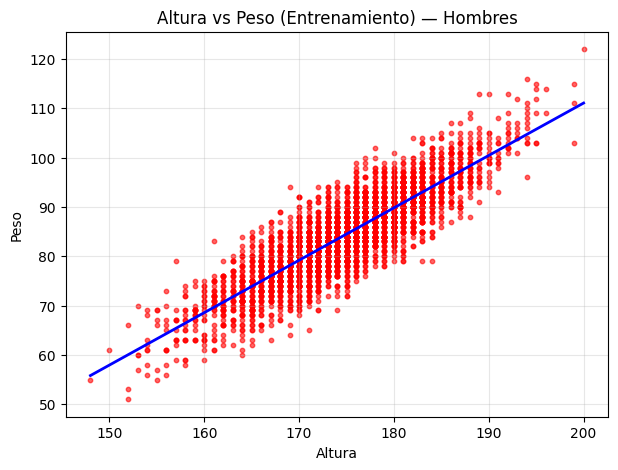

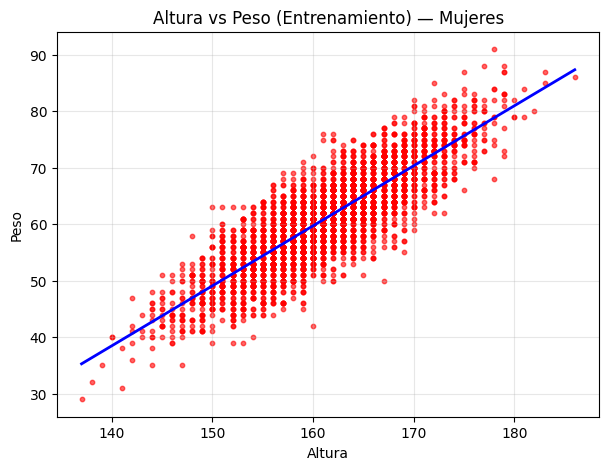

In [29]:
# Gráfico de Altura vs Peso por sexo, con la recta de regresión ajustada para cada grupo
for sexo_val, titulo in [(1, "Hombres"), (0, "Mujeres")]:
    mask = x_train['Sexo_num'] == sexo_val

    if mask.sum() == 0:
        print(f"No hay muestras de {titulo} en el conjunto de entrenamiento.")
        continue

    plt.figure(figsize=(7,5))

    # Puntos reales del grupo (Altura vs Peso)
    plt.scatter(
        x_train.loc[mask, 'Altura'],
        y_train.loc[mask].values.ravel(),
        color='red',
        s=10,
        alpha=0.6
    )

    # Recta de regresión: predicciones del modelo ordenadas por altura
    X_group = x_train.loc[mask, ['Altura', 'Sexo_num']]
    preds = Regressor.predict(X_group).ravel()
    order = X_group['Altura'].argsort()
    alturas_ordenadas = X_group['Altura'].iloc[order]
    preds_ordenadas = preds[order]

    plt.plot(alturas_ordenadas, preds_ordenadas, color='blue', linewidth=2)

    plt.title(f"Altura vs Peso (Entrenamiento) — {titulo}")
    plt.xlabel("Altura")
    plt.ylabel("Peso")
    plt.grid(alpha=0.3)
    plt.show()

# Métricas de evaluación del modelo

En esta ultima sección, se evalúa el rendimiento del modelo de regresión lineal utilizando el conjunto de prueba: primero genera las predicciones del modelo sobre datos que no fueron usados en el entrenamiento, luego convierte tanto los valores reales como los predichos en vectores unidimensionales para asegurar compatibilidad en el cálculo, y finalmente calcula tres métricas de desempeño (MSE, RMSE y R²) que permiten cuantificar el error de predicción y el nivel de ajuste del modelo.

In [30]:
# Evalúa el modelo en el conjunto de prueba con MSE, RMSE y R²
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = Regressor.predict(x_test)

# Asegura que los valores reales y predichos sean vectores 1D para el cálculo
y_true = y_test.values.ravel() if hasattr(y_test, "values") else np.array(y_test).ravel()
y_pred = np.array(y_pred).ravel()

mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2  = r2_score(y_true, y_pred)

print(f"MSE:  {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

MSE:  20.8434
RMSE: 4.5655
R²:   0.9030


Los resultados indican que el modelo tiene un desempeño bastante bueno: un MSE de 20.8434 muestra que el error cuadrático promedio es bajo en relación con la escala del peso, un RMSE de 4.5655 significa que, en promedio, las predicciones se desvían aproximadamente 4.6 kg del valor real, lo cual es razonable considerando que el peso humano suele variar en rangos amplios, y un R² de 0.9030 indica que el 90.3% de la variabilidad del peso es explicada por las variables altura y sexo, lo que confirma que el modelo logra capturar muy bien la relación entre estas variables y el peso.

# Conclusión

  Con los datos obtenidos, se analiza que el modelo de regresión lineal aplicado cumple de manera adecuada con el objetivo de predecir el peso a partir de la altura y el sexo, mostrando un ajuste satisfactorio en las medidas predictorias obtenidas. Pero, su validez depende del cumplimiento de ciertos supuestos como la relación lineal entre las variables, la independencia de los errores y demas variables que si no se cumplen completamente, el desempeño podría verse afectado. Entre las principales limitaciones se encuentra el uso de solo dos variables predictoras, ya que el peso corporal también puede depender de factores adicionales como edad, composición corporal o hábitos de vida, lo que restringe la capacidad explicativa del modelo. A pesar de ello, la calidad del ajuste observada es alta, lo que indica que el modelo logra capturar gran parte de la variabilidad del peso y resulta adecuado para fines predictivos básicos dentro del contexto analizado.